# Caso Discreto — Mega-Sena
## A Lei dos Grandes Números: frequência relativa $\to$ probabilidade

**Trabalho de Probabilidade — Aplicações da Lei dos Grandes Números (LGN)**

Este é o primeiro de dois estudos de caso. Aqui usamos o histórico de sorteios da
**Mega-Sena** — um fenômeno **discreto** cujas probabilidades são **conhecidas a
priori** — para ilustrar de forma limpa as duas faces da Lei dos Grandes Números:

1. **Frequência relativa $\to$ probabilidade:** a proporção observada de um evento
   converge para a probabilidade teórica do evento.
2. **Média amostral $\to$ esperança:** a média acumulada das observações converge
   para o valor esperado (a média populacional).

A grande vantagem deste caso é que **sabemos os alvos antes de olhar os dados**:
a probabilidade de uma dezena sair é exatamente $6/60 = 0{,}10$, e a média de uma
dezena sorteada é exatamente $30{,}5$. Isso transforma o dataset em um *laboratório*
para verificar a LGN — comparamos a curva empírica com uma reta horizontal cujo
valor já conhecemos.

> No segundo notebook (caso contínuo, retornos financeiros) a situação se inverte:
> o alvo $\mu$ é **estimado** dos próprios dados e a convergência é lenta e ruidosa.
> O contraste entre os dois casos é o argumento central do trabalho.


---
## 1. Fundamentação teórica

### 1.1 Esperança, variância e a média amostral

Seja $X_1, X_2, \dots, X_n$ uma sequência de variáveis aleatórias **independentes e
identicamente distribuídas** (i.i.d.), com esperança e variância finitas:

$$\mathbb{E}[X_i] = \mu, \qquad \operatorname{Var}(X_i) = \sigma^2 < \infty.$$

A **média amostral** após $n$ observações é

$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^{n} X_i.$$

### 1.2 Lei dos Grandes Números

**Lei Fraca (LFGN)** — convergência *em probabilidade*: para todo $\varepsilon > 0$,

$$\lim_{n\to\infty} \mathbb{P}\big(\,|\bar{X}_n - \mu| > \varepsilon\,\big) = 0.$$

**Lei Forte (LFoGN)** — convergência *quase certa* (mais forte):

$$\mathbb{P}\Big(\lim_{n\to\infty} \bar{X}_n = \mu\Big) = 1.$$

Intuitivamente: à medida que acumulamos observações, a média amostral fica
**arbitrariamente próxima** da esperança $\mu$ — e lá permanece.

### 1.3 Por que a convergência acontece — e em que ritmo

A média amostral é um estimador **não-viesado** de $\mu$, com variância que
**encolhe** com $n$:

$$\mathbb{E}[\bar{X}_n] = \mu, \qquad
\operatorname{Var}(\bar{X}_n) = \frac{\sigma^2}{n}.$$

Logo o **erro padrão** da média decai como

$$\operatorname{EP}(\bar{X}_n) = \frac{\sigma}{\sqrt{n}}.$$

Esse $\sigma/\sqrt{n}$ é a chave de todo o trabalho: a LGN vale para *qualquer*
distribuição com variância finita (**universalidade**), mas a **velocidade** depende
de $\sigma$. Na Mega-Sena $\sigma$ é moderado e o alvo é conhecido — a convergência é
visível e limpa.

### 1.4 Frequência relativa é um caso particular

Para um evento $A$, defina a variável indicadora $X_i = \mathbf{1}\{A \text{ ocorre no
ensaio } i\}$. Então $X_i \sim \text{Bernoulli}(p)$ com $\mathbb{E}[X_i] = p =
\mathbb{P}(A)$, e a média amostral é exatamente a **frequência relativa**:

$$\bar{X}_n = \frac{\#\{\text{ocorrências de } A\}}{n} \xrightarrow{\;n\to\infty\;} p.$$

Ou seja: *frequência relativa convergir para probabilidade* é só a LGN aplicada a
indicadores. É isso que vamos visualizar na Demonstração A.


---
## 2. Apresentação dos dados

O arquivo `data/sorteios.csv` contém o histórico de sorteios da Mega-Sena. Cada linha
é um concurso; cada concurso sorteia **6 dezenas distintas** entre **1 e 60**.

Vamos primeiro carregar os dados **crus** (sem nenhum tratamento) para inspecionar a
estrutura real do arquivo e identificar o que precisa de limpeza.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

CAMINHO = "../data/sorteios.csv"

# dtype=str preserva os zeros à esquerda das dezenas (ex.: "05") na inspeção inicial.
bruto = pd.read_csv(CAMINHO, encoding="utf-8", dtype=str)
print("Formato (linhas, colunas):", bruto.shape)
print("\nColunas encontradas:")
for c in bruto.columns:
    print(f"  - {repr(c)}")

Formato (linhas, colunas): (2278, 23)

Colunas encontradas:
  - 'Id'
  - 'Concurso'
  - 'Data Sorteio'
  - '1ª Dezena'
  - '2ª Dezena'
  - '3ª Dezena'
  - '4ª Dezena'
  - '5ª Dezena'
  - '6ª Dezena'
  - 'Arrecadacao_Total'
  - 'Ganhadores_Sena'
  - 'Cidade'
  - 'UF'
  - 'Rateio_Sena'
  - 'Ganhadores_Quina'
  - 'Rateio_Quina'
  - 'Ganhadores_Quadra'
  - 'Rateio_Quadra'
  - 'Acumulado'
  - 'Valor_Acumulado'
  - 'Estimativa_Prêmio'
  - 'Acumulado_Mega_da_Virada'
  - 'Unnamed: 22'


**O que observamos no arquivo cru** (pontos de atenção para a limpeza):

- As dezenas vêm como texto com **zero à esquerda** (`"05"`, `"04"`) — precisam virar
  inteiros.
- A última coluna é **vazia / sem nome** (o cabeçalho termina em vírgula). O pandas a
  rotula como `Unnamed: ...`.
- Há uma coluna `Id` (sequencial) além de `Concurso` (o número oficial do concurso).
- As datas estão em `dd/mm/aaaa`.
- Há muitas colunas de **premiação** (`Arrecadacao_Total`, `Rateio_Sena`, ...) em
  formato monetário brasileiro (`"39.158,92"`). **Nenhuma delas é necessária** para a
  LGN — só nos interessam as 6 dezenas e, para ordenar, a data.


In [2]:
# Espiando as primeiras linhas só das colunas que vamos usar:
bruto[["Id", "Concurso", "Data Sorteio",
       "1ª Dezena", "2ª Dezena", "3ª Dezena",
       "4ª Dezena", "5ª Dezena", "6ª Dezena"]].head()

,Id,Concurso,Data Sorteio,1ª Dezena,2ª Dezena,3ª Dezena,4ª Dezena,5ª Dezena,6ª Dezena
0,1,1,11/03/1996,41,05,04,52,30,33
1,2,2,18/03/1996,09,39,37,49,43,41
2,3,3,25/03/1996,36,30,10,11,29,47
3,4,3,25/03/1996,36,30,10,11,29,47
4,5,4,01/04/1996,06,59,42,27,01,05


---
## 3. Raspagem e limpeza dos dados

Os dados já estão em CSV local (não há *scraping* de web aqui), então a "raspagem"
consiste em **extrair** do arquivo apenas o que importa e **higienizar** os tipos.
Passos:

1. Selecionar somente `Concurso`, `Data Sorteio` e as 6 colunas de dezenas
   (descartando premiação e a coluna vazia final).
2. Converter `Data Sorteio` para `datetime` (formato `dd/mm/aaaa`).
3. Converter as 6 dezenas de texto para inteiro (some o zero à esquerda).
4. **Ordenar cronologicamente** pela data — a LGN é sobre acumular observações *na
   ordem em que ocorrem*, então a ordem temporal importa.


In [3]:
cols_dezenas = ["1ª Dezena", "2ª Dezena", "3ª Dezena",
                "4ª Dezena", "5ª Dezena", "6ª Dezena"]

df = bruto[["Concurso", "Data Sorteio"] + cols_dezenas].copy()

# Data: dd/mm/aaaa -> datetime
df["Data Sorteio"] = pd.to_datetime(df["Data Sorteio"], format="%d/%m/%Y")

# Concurso e dezenas: texto -> inteiro
df["Concurso"] = df["Concurso"].astype(int)
for c in cols_dezenas:
    df[c] = df[c].astype(int)

# Ordem cronológica (a "linha do tempo" sobre a qual a LGN acumula).
df = df.sort_values(["Data Sorteio", "Concurso"]).reset_index(drop=True)

df.head()

,Concurso,Data Sorteio,1ª Dezena,2ª Dezena,3ª Dezena,4ª Dezena,5ª Dezena,6ª Dezena
0,1,1996-03-11,41,5,4,52,30,33
1,2,1996-03-18,9,39,37,49,43,41
2,3,1996-03-25,36,30,10,11,29,47
3,3,1996-03-25,36,30,10,11,29,47
4,4,1996-04-01,6,59,42,27,1,5


### 3.1 Verificações de sanidade

Antes de qualquer análise, confirmamos que os dados limpos batem com o que sabemos
da Mega-Sena. Esses *sanity checks* protegem contra erros silenciosos de parsing.


In [4]:
n_sorteios = len(df)

# Empilhamos as 6 colunas em uma única série, percorrendo SORTEIO A SORTEIO
# (ordem C do numpy: linha por linha) -> preserva a ordem cronológica dos concursos.
dezenas = df[cols_dezenas].to_numpy().ravel()

print(f"Nº de sorteios .................. {n_sorteios}")
print(f"Total de dezenas (6 x sorteios) . {dezenas.size}")
print(f"Valor mínimo / máximo .......... {dezenas.min()} / {dezenas.max()}")
print(f"Dezenas distintas em todo período {np.unique(dezenas).size} (esperado: 60)")
print(f"Todo sorteio tem 6 distintas? .. {bool((df[cols_dezenas].nunique(axis=1) == 6).all())}")
print(f"Período ........................ {df['Data Sorteio'].min().date()}"
      f" a {df['Data Sorteio'].max().date()}")
print()
print(f"Média observada das dezenas .... {dezenas.mean():.4f}")
print(f"Média teórica (centro de 1..60)  {(1 + 60) / 2:.4f}")

Nº de sorteios .................. 2278
Total de dezenas (6 x sorteios) . 13668
Valor mínimo / máximo .......... 1 / 60
Dezenas distintas em todo período 60 (esperado: 60)
Todo sorteio tem 6 distintas? .. True
Período ........................ 1996-03-11 a 2018-07-25

Média observada das dezenas .... 30.2166
Média teórica (centro de 1..60)  30.5000


Tudo confere: **2.278 sorteios**, **13.668 dezenas** empilhadas, valores em
$\{1, \dots, 60\}$, 6 distintas por sorteio, e a média observada (~$30{,}2$) já está
próxima da teórica ($30{,}5$). Os dados estão prontos para a análise.


---
## 4. Os alvos teóricos

Antes de medir, deduzimos os valores para os quais as curvas **devem** convergir.

### 4.1 Probabilidade de uma dezena fixa sair

Em cada sorteio escolhem-se 6 dezenas distintas entre 60, todas as combinações
$\binom{60}{6}$ igualmente prováveis. Fixe uma dezena $k$. O número de sorteios que
**contêm** $k$ é $\binom{59}{5}$ (escolhemos as outras 5 entre as 59 restantes). Logo

$$\mathbb{P}(k \text{ sai em um sorteio}) = \frac{\binom{59}{5}}{\binom{60}{6}}
= \frac{6}{60} = \frac{1}{10} = 0{,}10.$$

Pela simetria, isso vale para **qualquer** das 60 dezenas. Este é o alvo da
Demonstração A: $p = 0{,}10$.

### 4.2 Frequência de cada número no total de dezenas

Empilhando todas as $13.668$ dezenas, cada número de 1 a 60 é igualmente provável de
ocupar uma posição qualquer, então sua frequência relativa deve convergir para

$$\frac{1}{60} \approx 0{,}01667.$$

### 4.3 Média de uma dezena sorteada (esperança)

A distribuição marginal de uma dezena sorteada é **uniforme** em $\{1, \dots, 60\}$.
Sua esperança é o centro do intervalo:

$$\mu = \mathbb{E}[X] = \frac{1}{60}\sum_{j=1}^{60} j = \frac{1 + 60}{2} = 30{,}5.$$

E a variância da uniforme discreta em $\{1, \dots, 60\}$ é

$$\sigma^2 = \frac{60^2 - 1}{12} = \frac{3599}{12} \approx 299{,}9,
\qquad \sigma \approx 17{,}32.$$

Esse $\sigma$ vai nos dar a *faixa teórica* $\mu \pm \sigma/\sqrt{n}$ na Demonstração B.


In [5]:
from math import comb

p_dezena = comb(59, 5) / comb(60, 6)
mu = (1 + 60) / 2
var_teo = (60**2 - 1) / 12
sigma_teo = var_teo ** 0.5

print(f"P(dezena fixa sair) = C(59,5)/C(60,6) = {p_dezena:.4f}  (= 6/60)")
print(f"Frequência por número no total       = 1/60 = {1/60:.5f}")
print(f"Esperança  mu    = {mu}")
print(f"Variância  sigma^2 = {var_teo:.4f}")
print(f"Desvio     sigma   = {sigma_teo:.4f}")

P(dezena fixa sair) = C(59,5)/C(60,6) = 0.1000  (= 6/60)
Frequência por número no total       = 1/60 = 0.01667
Esperança  mu    = 30.5
Variância  sigma^2 = 299.9167
Desvio     sigma   = 17.3181


---
## 5. Demonstração A — Frequência relativa $\to$ probabilidade

Escolhemos uma dezena $k$ (aqui, $k = 10$) e construímos a indicadora por sorteio:

$$X_i = \mathbf{1}\{\text{o sorteio } i \text{ contém a dezena } k\},
\qquad X_i \sim \text{Bernoulli}(0{,}10).$$

A frequência relativa acumulada após $n$ sorteios é

$$\hat{p}_n = \frac{1}{n}\sum_{i=1}^{n} X_i.$$

A LGN garante $\hat{p}_n \to p = 0{,}10$. Vamos plotar $\hat{p}_n$ contra $n$.


Frequência final (n=2278): 0.1212  |  alvo: 0.1000


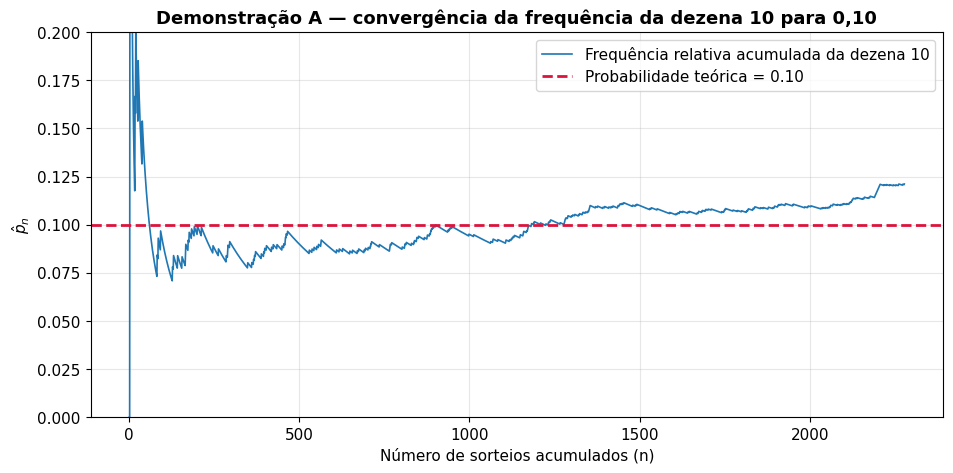

In [6]:
DEZENA = 10

# Indicadora: o sorteio i contém a dezena escolhida?
contem = df[cols_dezenas].eq(DEZENA).any(axis=1).to_numpy().astype(int)

n_eixo = np.arange(1, n_sorteios + 1)
freq_acum = np.cumsum(contem) / n_eixo   # p-chapéu_n

fig, ax = plt.subplots()
ax.plot(n_eixo, freq_acum, lw=1.2, color="#1f77b4",
        label=f"Frequência relativa acumulada da dezena {DEZENA}")
ax.axhline(p_dezena, color="crimson", ls="--", lw=2,
           label=f"Probabilidade teórica = {p_dezena:.2f}")
ax.set_xlabel("Número de sorteios acumulados (n)")
ax.set_ylabel(r"$\hat{p}_n$")
ax.set_title(f"Demonstração A — convergência da frequência da dezena {DEZENA} para 0,10")
ax.set_ylim(0, 0.2)
ax.legend()
print(f"Frequência final (n={n_sorteios}): {freq_acum[-1]:.4f}  |  alvo: {p_dezena:.4f}")
plt.show()

**Lendo o gráfico.** No início (poucos sorteios) a curva é **errática**: com $n$
pequeno, um único sorteio entra com peso $1/n$ grande, então $\hat{p}_n$ salta entre
$0$ e $0{,}2$. À medida que $n$ cresce, as oscilações **amortecem** e a curva se
estabiliza numa faixa estreita em torno da reta vermelha. Esse amortecimento das
oscilações é a assinatura visual da LGN.

**Honestidade sobre o valor final.** A curva termina em $\approx 0{,}121$, e *não*
exatamente em $0{,}10$. Isso não contradiz a LGN — é flutuação amostral esperada.
O erro padrão de $\hat{p}_n$ é $\sqrt{p(1-p)/n} = \sqrt{0{,}1\cdot 0{,}9 / 2278}
\approx 0{,}0063$, então o desvio observado ($\approx 0{,}021$) equivale a cerca de
$3{,}4$ erros padrão. De fato, a dezena 10 está **entre as mais sorteadas** de todo o período
(empatada com a dezena 5, ambas com 276 aparições em 2278 sorteios; veja o gráfico de
barras adiante) — recaímos justamente em um dos casos "mais difíceis" e,
ainda assim, a frequência ficou na casa de $0{,}12$. A lição é dupla: (i) a LGN é uma
afirmação *no limite* $n\to\infty$, e $2.278$ ensaios ainda é pouco para um evento de
$p = 0{,}1$; (ii) é o **afunilamento** das oscilações, não a igualdade exata em $n$
finito, que evidencia a convergência. O erro típico cai de $\approx 0{,}03$ em
$n=100$ para $\approx 0{,}006$ em $n=2278$ — encolhendo como $1/\sqrt{n}$.

### 5.1 Robustez — não foi sorte da dezena escolhida

Para mostrar que o fenômeno não depende do número $k$ escolhido, repetimos a curva
para **várias** dezenas ao mesmo tempo. Todas convergem para a mesma reta $0{,}10$.


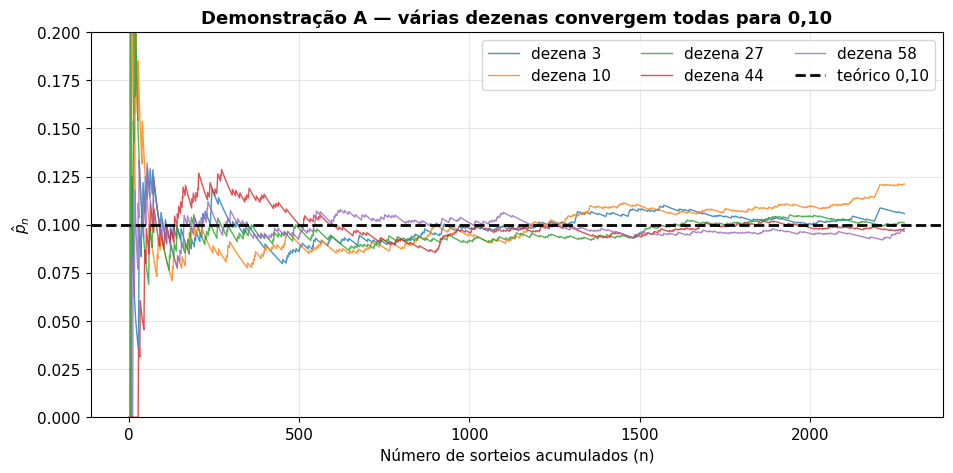

In [7]:
fig, ax = plt.subplots()
for k in [3, 10, 27, 44, 58]:
    ind = df[cols_dezenas].eq(k).any(axis=1).to_numpy().astype(int)
    ax.plot(n_eixo, np.cumsum(ind) / n_eixo, lw=1, alpha=0.8, label=f"dezena {k}")
ax.axhline(p_dezena, color="black", ls="--", lw=2, label="teórico 0,10")
ax.set_xlabel("Número de sorteios acumulados (n)")
ax.set_ylabel(r"$\hat{p}_n$")
ax.set_title("Demonstração A — várias dezenas convergem todas para 0,10")
ax.set_ylim(0, 0.2)
ax.legend(ncol=3)
plt.show()

### 5.2 Visão complementar — frequência de cada número no total

Em vez de acompanhar a convergência *ao longo do tempo*, podemos olhar o **resultado
final**: empilhando as 13.668 dezenas, qual a frequência relativa de cada número de
1 a 60? A LGN prevê que todas fiquem próximas de $1/60 \approx 0{,}0167$.


Desvio das frequências em torno de 1/60: min=0.0128, max=0.0202, amplitude=0.0074


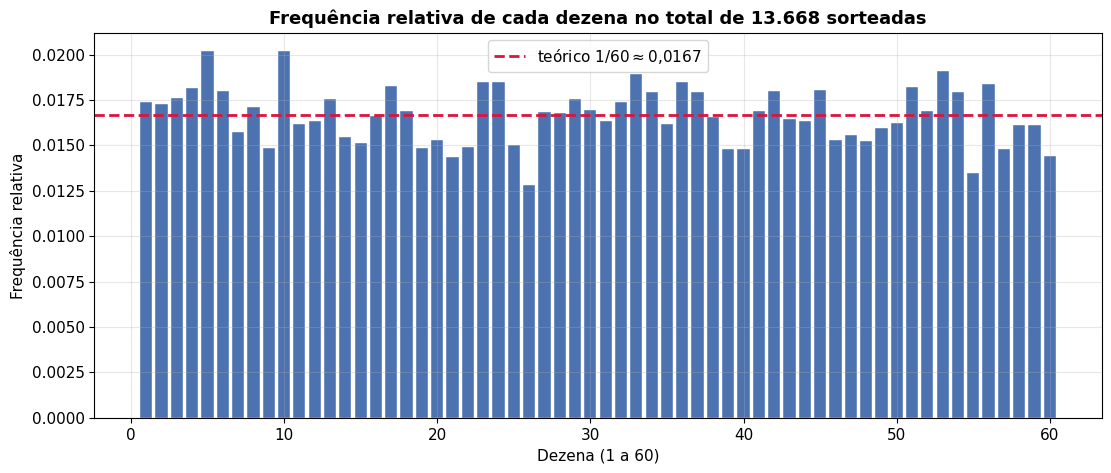

In [8]:
valores, contagens = np.unique(dezenas, return_counts=True)
freq_rel = contagens / dezenas.size

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(valores, freq_rel, color="#4c72b0", edgecolor="white", linewidth=0.3)
ax.axhline(1/60, color="crimson", ls="--", lw=2, label=r"teórico $1/60 \approx 0{,}0167$")
ax.set_xlabel("Dezena (1 a 60)")
ax.set_ylabel("Frequência relativa")
ax.set_title("Frequência relativa de cada dezena no total de 13.668 sorteadas")
ax.legend()
print(f"Desvio das frequências em torno de 1/60: "
      f"min={freq_rel.min():.4f}, max={freq_rel.max():.4f}, "
      f"amplitude={(freq_rel.max()-freq_rel.min()):.4f}")
plt.show()

**Lendo o gráfico.** As 60 barras oscilam em torno da reta $1/60$, sem nenhum
número se destacar de forma sistemática. As pequenas diferenças entre barras são
**flutuação amostral** (ruído), não viés: com "apenas" 13.668 dezenas, é esperado que
as frequências não sejam idênticas. Isso é coerente com a hipótese de sorteio justo —
e ilustra que a LGN descreve uma tendência *no limite*, não igualdade exata em $n$
finito.


---
## 6. Demonstração B — Média amostral $\to$ esperança

Agora tratamos a sequência das **13.668 dezenas** (na ordem dos concursos) como as
observações $X_1, X_2, \dots$ e acompanhamos a média acumulada

$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^{n} X_i \xrightarrow{\;n\to\infty\;} \mu = 30{,}5.$$


Média final (n=13668): 30.2166  |  alvo: 30.5


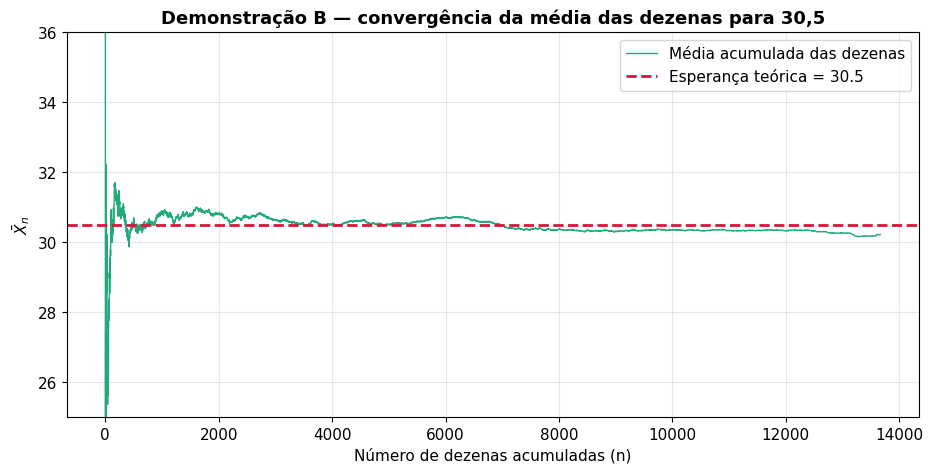

In [9]:
n_dez = np.arange(1, dezenas.size + 1)
media_acum = np.cumsum(dezenas) / n_dez

fig, ax = plt.subplots()
ax.plot(n_dez, media_acum, lw=1.0, color="#2a7", label="Média acumulada das dezenas")
ax.axhline(mu, color="crimson", ls="--", lw=2, label=f"Esperança teórica = {mu}")
ax.set_xlabel("Número de dezenas acumuladas (n)")
ax.set_ylabel(r"$\bar{X}_n$")
ax.set_title("Demonstração B — convergência da média das dezenas para 30,5")
ax.set_ylim(25, 36)
ax.legend()
print(f"Média final (n={dezenas.size}): {media_acum[-1]:.4f}  |  alvo: {mu}")
plt.show()

**Lendo o gráfico.** Mesma assinatura da Demonstração A: forte oscilação inicial,
depois convergência suave para $30{,}5$. A média final ($\approx 30{,}2$) fica muito
perto do alvo. O pequeno desvio residual é compatível com o erro padrão em
$n = 13.668$: $\sigma/\sqrt{n} \approx 17{,}32/\sqrt{13668} \approx 0{,}15$.

### 6.1 A faixa teórica $\mu \pm \sigma/\sqrt{n}$

Podemos sobrepor à média acumulada a faixa de $\pm 2$ erros padrão prevista pela
teoria, $\mu \pm 2\sigma/\sqrt{n}$. Se a LGN (e a aproximação i.i.d.) valem, a curva
empírica deve permanecer **dentro** dessa faixa na maior parte do tempo, e a faixa
deve **afunilar** como $1/\sqrt{n}$.


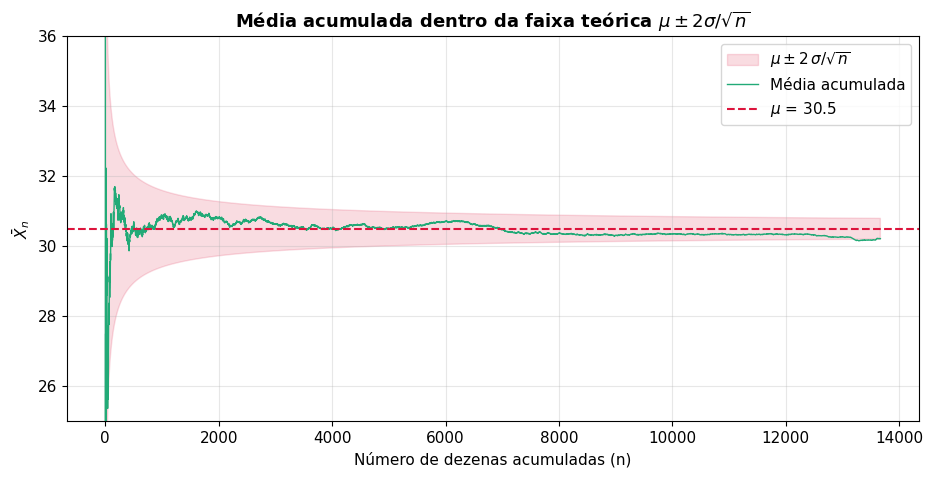

In [10]:
ep = sigma_teo / np.sqrt(n_dez)          # erro padrão teórico
sup, inf = mu + 2 * ep, mu - 2 * ep

fig, ax = plt.subplots()
ax.fill_between(n_dez, inf, sup, color="crimson", alpha=0.15,
                label=r"$\mu \pm 2\,\sigma/\sqrt{n}$")
ax.plot(n_dez, media_acum, lw=1.0, color="#2a7", label="Média acumulada")
ax.axhline(mu, color="crimson", ls="--", lw=1.5, label=f"$\\mu$ = {mu}")
ax.set_xlabel("Número de dezenas acumuladas (n)")
ax.set_ylabel(r"$\bar{X}_n$")
ax.set_title(r"Média acumulada dentro da faixa teórica $\mu \pm 2\sigma/\sqrt{n}$")
ax.set_ylim(25, 36)
ax.legend()
plt.show()

**Lendo o gráfico.** A média empírica mergulha rapidamente para dentro do funil
vermelho e ali permanece — é a confirmação visual de que o erro decai na taxa
$\sigma/\sqrt{n}$ prevista pela teoria. A largura da faixa cai pela metade quando $n$
quadruplica: para *ganhar um dígito de precisão* precisamos de **100×** mais dados.
Essa é a má notícia escondida na LGN — e ela será dramática no caso contínuo.


---
## 7. Discussão crítica

### 7.1 Por que a convergência aqui é tão "limpa"

Três fatores tornam este caso o cenário ideal da LGN:

- **Probabilidade bem definida e simétrica:** o mecanismo do sorteio garante
  $p = 0{,}10$ e $\mu = 30{,}5$ por construção.
- **Variância moderada frente à escala:** o coeficiente de variação de uma dezena é
  $\sigma/\mu \approx 17{,}3/30{,}5 \approx 0{,}57$ — baixo. (No caso contínuo dos
  retornos esse coeficiente passa de $17\times$, daí a convergência arrastada.)
- **Alvo conhecido a priori:** comparamos a curva com uma reta cujo valor *deduzimos*,
  não estimamos. Não há risco de "acertar o alvo no próprio dado".

### 7.2 A hipótese i.i.d. — honestidade analítica

A LGN clássica supõe observações **i.i.d.** Vale checar o quanto isso se sustenta:

- **Entre sorteios:** os concursos são fisicamente independentes (o globo não tem
  memória). Hipótese de **independência plausível**. ✔
- **Dentro de um sorteio:** as 6 dezenas são sorteadas **sem reposição**, logo
  **não são independentes entre si** (saber 5 dezenas restringe a 6ª). [aproximação]

Ou seja, ao empilhar as 6 dezenas tratando-as como uma sequência i.i.d. estamos
fazendo uma **aproximação**. Felizmente o efeito é pequeno: a dependência é fraca
(6 entre 60) e *identicamente distribuída* (cada posição é marginalmente uniforme),
então a LGN continua valendo para a média — e os gráficos confirmam. Este é um bom
exemplo de que a LGN é **robusta** a violações brandas das hipóteses.

### 7.3 LGN fraca vs. forte neste caso

O que enxergamos nos gráficos — uma única trajetória $\bar{X}_n$ aproximando-se de
$\mu$ e *permanecendo* lá — é a intuição da **Lei Forte** (convergência quase certa
da trajetória). A **Lei Fraca** faria uma afirmação sobre a probabilidade de
$\bar{X}_n$ estar longe de $\mu$ para cada $n$ fixo. Para fins práticos de
visualização, ambas dizem a mesma coisa: a curva converge.


---
## 8. Conclusão

Usando o histórico real da Mega-Sena, verificamos empiricamente as duas faces da
Lei dos Grandes Números:

| Demonstração | Quantidade | Alvo teórico | Resultado |
|---|---|---|---|
| **A** — frequência $\to$ probabilidade | $\hat{p}_n$ da dezena | $0{,}10$ | oscilações amortecem; termina em $0{,}121$ ($\approx 3{,}4$ EP) |
| **A'** — freq. de cada número | $13.668$ dezenas | $1/60 \approx 0{,}0167$ | todas entre $0{,}013$ e $0{,}020$, sem viés sistemático |
| **B** — média $\to$ esperança | média das dezenas | $30{,}5$ | converge para $30{,}22$, dentro de $\mu \pm 2\sigma/\sqrt{n}$ |

**Mensagens centrais:**

1. *Frequência relativa converge para probabilidade* é a LGN aplicada a indicadores
   de Bernoulli.
2. A convergência é **suave e rápida** porque a variância é moderada e os alvos são
   conhecidos por construção.
3. O erro decai como $\sigma/\sqrt{n}$ — visível no afunilamento das curvas e da faixa
   teórica. Ganhar precisão custa caro: $100\times$ mais dados por dígito.

**Ponte para o próximo notebook.** No caso contínuo (retornos diários de uma ação) a
esperança $\mu$ é *minúscula* frente a um $\sigma$ enorme (coeficiente de variação
$\approx 17\times$). A LGN continua valendo — **universalidade** —, mas a convergência
será lenta e ruidosa. O contraste entre os dois casos mostra que o que muda de um
fenômeno para outro não é *se* a LGN vale, mas *quão rápido*.
